# Hedge candidate rebalancing visual comparison

A decision-first comparison of the Asteria hedge candidates under **sequential rebalancing stress**: what changes, what fills, what it costs, whether execution is delayed, and how the rebalanced terminal result compares with the static stressed hedge.

> Run all cells from the repository root or from `notebooks/`. Every result is rebuilt from the case YAML, portfolio, mandate, policy, and market-history inputs; no stress result is hard-coded.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

search_roots = (Path.cwd().resolve(), *Path.cwd().resolve().parents)
ROOT = next(path for path in search_roots if (path / 'src' / 'quant_hedge_desk').is_dir())
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

from quant_hedge_desk.application.stress_candidate_hedge import stress_candidate_hedges
from quant_hedge_desk.data.loaders import load_portfolio_csv

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi': 120, 'axes.titleweight': 'bold',
    'axes.spines.top': False, 'axes.spines.right': False,
})
COLORS = {
    'Hybrid puts': '#0072B2',
    'Vertical spread': '#E69F00',
    'Protective put': '#009E73',
}
PASS_FAIL_CMAP = ListedColormap(['#C94C4C', '#3A9D5D'])
ROOT

WindowsPath('E:/Quant Projects/Portfolio Project/quant-hedge-desk-src/quant-hedge-desk')

## 1. Build comparable rebalancing evidence

Both runs use the same portfolio, mandate, candidates, historical horizon returns, and three-step loss path. They differ only in how option trades are marked: model-based Black-76 repricing versus supplied explicit marks. A rebalancing failure is a release gate in both policies.

In [2]:
case_dir = ROOT / 'cases' / 'asteria_capital'
candidate_paths = tuple(sorted(case_dir.glob('candidate_*.yaml')))
candidate_labels = {
    'asteria-hybrid-protective-puts-v1': 'Hybrid puts',
    'asteria-nifty-vertical-put-spread-v1': 'Vertical spread',
    'asteria-nifty-protective-put-v1': 'Protective put',
}
common = {
    'portfolio_path': case_dir / 'portfolio.csv',
    'mandate_path': case_dir / 'mandate.yaml',
    'candidate_paths': candidate_paths,
    'market_data_path': ROOT / 'data' / 'market' / 'eod_prices.csv',
}
run_specs = {
    'Black-76 repricing': {
        'stress_scenario_path': case_dir / 'rebalancing_stress_delayed_black76.yaml',
        'rebalancing_policy_path': case_dir / 'rebalancing_stress_policy.yaml',
    },
    'Explicit marks': {
        'stress_scenario_path': case_dir / 'rebalancing_stress_explicit_marks.yaml',
        'rebalancing_policy_path': case_dir / 'rebalancing_stress_explicit_policy.yaml',
    },
}
batches = {mode: stress_candidate_hedges(**common, **spec) for mode, spec in run_specs.items()}
portfolio_value = float(load_portfolio_csv(common['portfolio_path']).total_market_value)

summary_rows = []
for mode, batch in batches.items():
    for evaluation in batch.evaluations:
        outcome = evaluation.outcomes[0]
        summary_rows.append({
            'Mode': mode,
            'Candidate': candidate_labels[evaluation.candidate_id],
            'Static stressed return': float(outcome.stressed_hedged_return),
            'Rebalanced return': float(outcome.rebalanced_hedged_return),
            'Rebalancing delta': float(outcome.rebalanced_hedged_return - outcome.stressed_hedged_return),
            'Turnover / portfolio': float(outcome.rebalance_turnover) / portfolio_value,
            'Rebalance cost / portfolio': float(outcome.cumulative_rebalance_cost) / portfolio_value,
            'Premium cash flow / portfolio': float(outcome.rebalanced_premium_cash_flow) / portfolio_value,
            'Maximum delay': outcome.maximum_rebalance_delay_trading_days,
            'Rebalancing gate': 'PASS' if outcome.rebalancing_pass else 'FAIL',
            'Overall release gate': 'PASS' if outcome.passed else 'FAIL',
        })
summary = pd.DataFrame(summary_rows).set_index(['Mode', 'Candidate'])
display(summary.style.format({
    'Static stressed return': '{:.2%}', 'Rebalanced return': '{:.2%}',
    'Rebalancing delta': '{:+.2%}', 'Turnover / portfolio': '{:.2%}',
    'Rebalance cost / portfolio': '{:.3%}', 'Premium cash flow / portfolio': '{:+.2%}',
    'Maximum delay': '{:.0f} days',
}).map(
    lambda value: 'color: #17803d; font-weight: bold' if value == 'PASS' else (
        'color: #b42318; font-weight: bold' if value == 'FAIL' else ''
    ), subset=['Rebalancing gate', 'Overall release gate']
))

## 2. Static versus rebalanced terminal result

Higher bars are better because they represent a smaller loss. The comparison isolates the result of sequential resizing and its cash ledger from the static stressed hedge result produced for the same path.

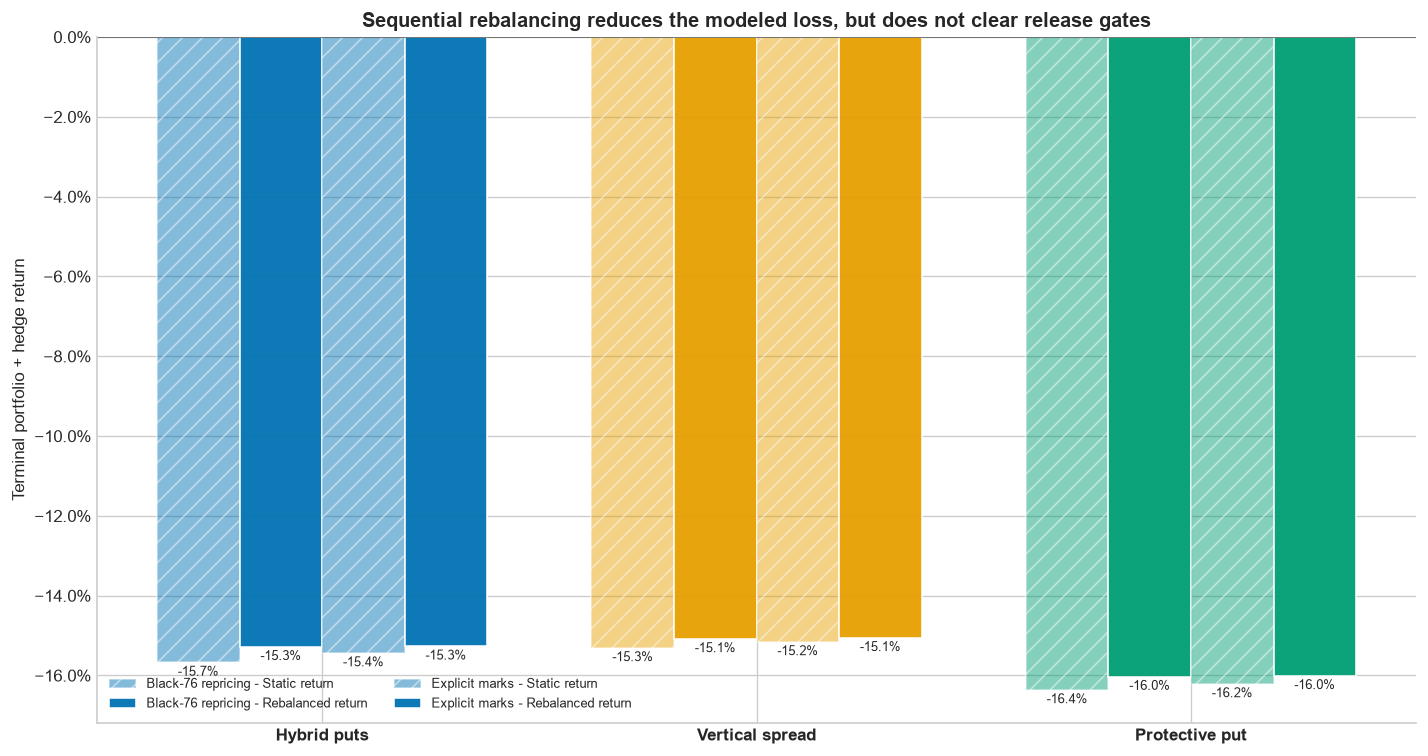

In [3]:
candidates = list(COLORS)
modes = list(run_specs)
x = np.arange(len(candidates))
width = 0.19
fig, ax = plt.subplots(figsize=(12, 6.4))
for mode_idx, mode in enumerate(modes):
    mode_rows = summary.loc[mode].reindex(candidates)
    for result_idx, (column, hatch) in enumerate((
        ('Static stressed return', '//'), ('Rebalanced return', ''),
    )):
        offset = (mode_idx * 2 + result_idx - 1.5) * width
        bars = ax.bar(
            x + offset, mode_rows[column], width,
            color=[COLORS[item] for item in candidates],
            alpha=0.48 if result_idx == 0 else 0.95, hatch=hatch,
            edgecolor='white',
            label=f'{mode} - {column.replace(" stressed", "")}',
        )
        ax.bar_label(bars, labels=[f'{value:.1%}' for value in mode_rows[column]], padding=2, fontsize=8)
ax.axhline(0, color='#555555', linewidth=0.9)
ax.set_xticks(x, candidates, fontweight='bold')
ax.set_ylabel('Terminal portfolio + hedge return')
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_title('Sequential rebalancing reduces the modeled loss, but does not clear release gates')
ax.legend(frameon=False, ncol=2, fontsize=8, loc='lower left')
plt.tight_layout()
plt.show()

## 3. Release-gate map

The overall decision combines the original static stress checks with the sequential rebalancing gate. Green means that one check passes; it does not override a red check elsewhere in the row.

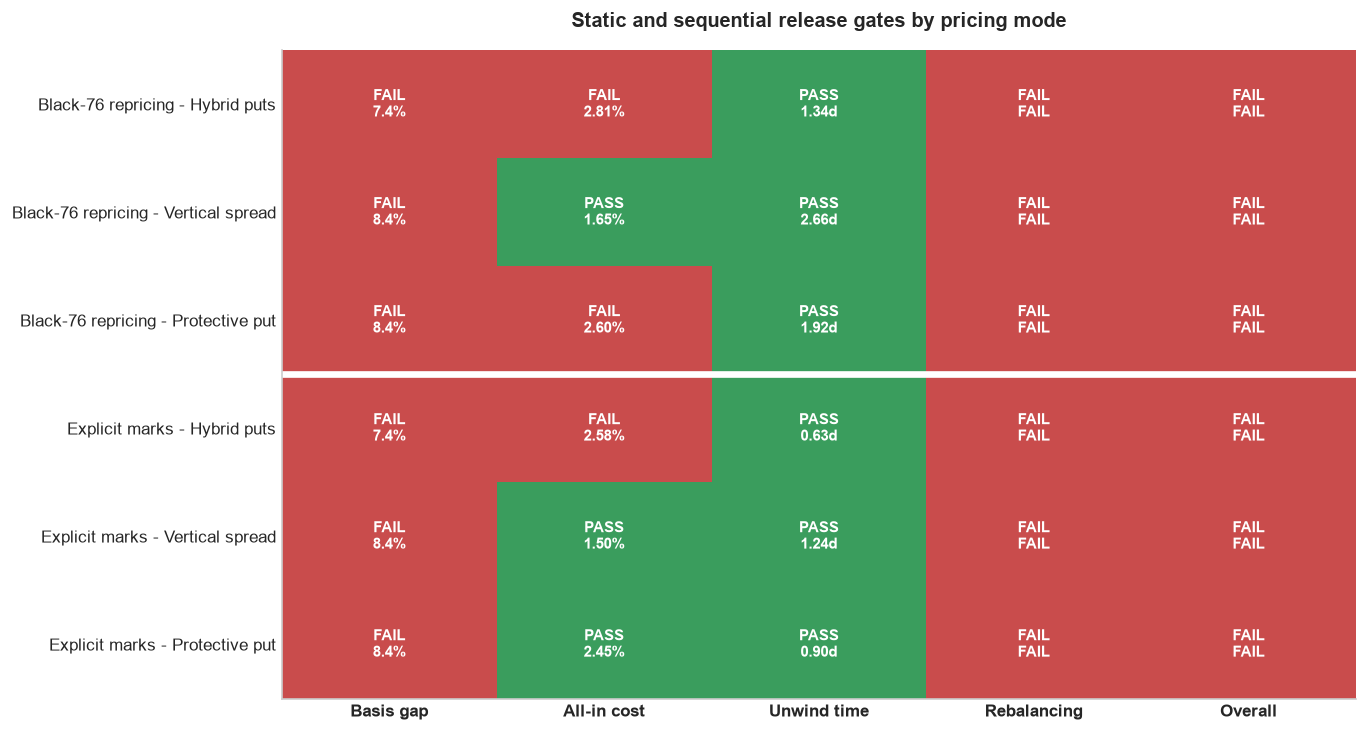

In [4]:
gate_columns = ['Basis gap', 'All-in cost', 'Unwind time', 'Rebalancing', 'Overall']
gate_rows, gate_values, gate_annotations = [], [], []
for mode, batch in batches.items():
    for evaluation in batch.evaluations:
        outcome = evaluation.outcomes[0]
        gate_rows.append(f'{mode} - {candidate_labels[evaluation.candidate_id]}')
        values = [
            outcome.correlation_pass, outcome.cost_budget_pass, outcome.liquidity_pass,
            outcome.rebalancing_pass, outcome.passed,
        ]
        gate_values.append([int(value) for value in values])
        gate_annotations.append([
            f'{float(outcome.absolute_correlation_basis_gap):.1%}',
            f'{float(outcome.stressed_all_in_cost_fraction):.2%}',
            f'{float(outcome.stressed_unwind_days):.2f}d',
            'PASS' if outcome.rebalancing_pass else 'FAIL',
            'PASS' if outcome.passed else 'FAIL',
        ])
gate_values = np.asarray(gate_values)
fig, ax = plt.subplots(figsize=(11.5, 6.2))
ax.imshow(gate_values, cmap=PASS_FAIL_CMAP, vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(len(gate_columns)), gate_columns, fontweight='bold')
ax.set_yticks(range(len(gate_rows)), gate_rows)
for row in range(gate_values.shape[0]):
    for col in range(gate_values.shape[1]):
        mark = 'PASS' if gate_values[row, col] else 'FAIL'
        ax.text(col, row, f'{mark}\n{gate_annotations[row][col]}', ha='center', va='center', color='white', fontweight='bold', fontsize=9)
ax.axhline(2.5, color='white', linewidth=4)
ax.set_title('Static and sequential release gates by pricing mode', pad=14)
ax.grid(False)
ax.tick_params(length=0)
plt.tight_layout()
plt.show()

## 4. Rebalance event ledger and execution timeline

The first exceptional resize is blocked. When trading resumes, the engine recalculates the target from the new portfolio value and market state instead of replaying a stale order. Gross requested and filled contracts make partial or failed execution visible.

,Mode,Candidate,Step,Trigger,Gross requested contracts,Gross filled contracts,Delay,Turnover / portfolio,Premium cash flow / portfolio,Execution cost / portfolio,Constraint,Failure
0,Black-76 repricing,Hybrid puts,1,EXCEPTIONAL,419,0,0 days,0.00%,+0.000%,0.000%,-,REBALANCING_NOT_ALLOWED
1,Black-76 repricing,Hybrid puts,2,EXCEPTIONAL,470,470,1 days,6.29%,+0.209%,0.035%,FEASIBLE,-
4,Black-76 repricing,Protective put,1,EXCEPTIONAL,475,0,0 days,0.00%,+0.000%,0.000%,-,REBALANCING_NOT_ALLOWED
5,Black-76 repricing,Protective put,2,EXCEPTIONAL,538,538,1 days,6.68%,+0.205%,0.024%,FEASIBLE,-
2,Black-76 repricing,Vertical spread,1,EXCEPTIONAL,1118,0,0 days,0.00%,+0.000%,0.000%,-,REBALANCING_NOT_ALLOWED
3,Black-76 repricing,Vertical spread,2,EXCEPTIONAL,1266,1266,1 days,15.71%,+0.104%,0.024%,FEASIBLE,-
6,Explicit marks,Hybrid puts,1,EXCEPTIONAL,419,0,0 days,0.00%,+0.000%,0.000%,-,REBALANCING_NOT_ALLOWED
7,Explicit marks,Hybrid puts,2,EXCEPTIONAL,470,470,1 days,6.29%,+0.204%,0.017%,FEASIBLE,-
10,Explicit marks,Protective put,1,EXCEPTIONAL,475,0,0 days,0.00%,+0.000%,0.000%,-,REBALANCING_NOT_ALLOWED
11,Explicit marks,Protective put,2,EXCEPTIONAL,538,538,1 days,6.68%,+0.213%,0.012%,FEASIBLE,-


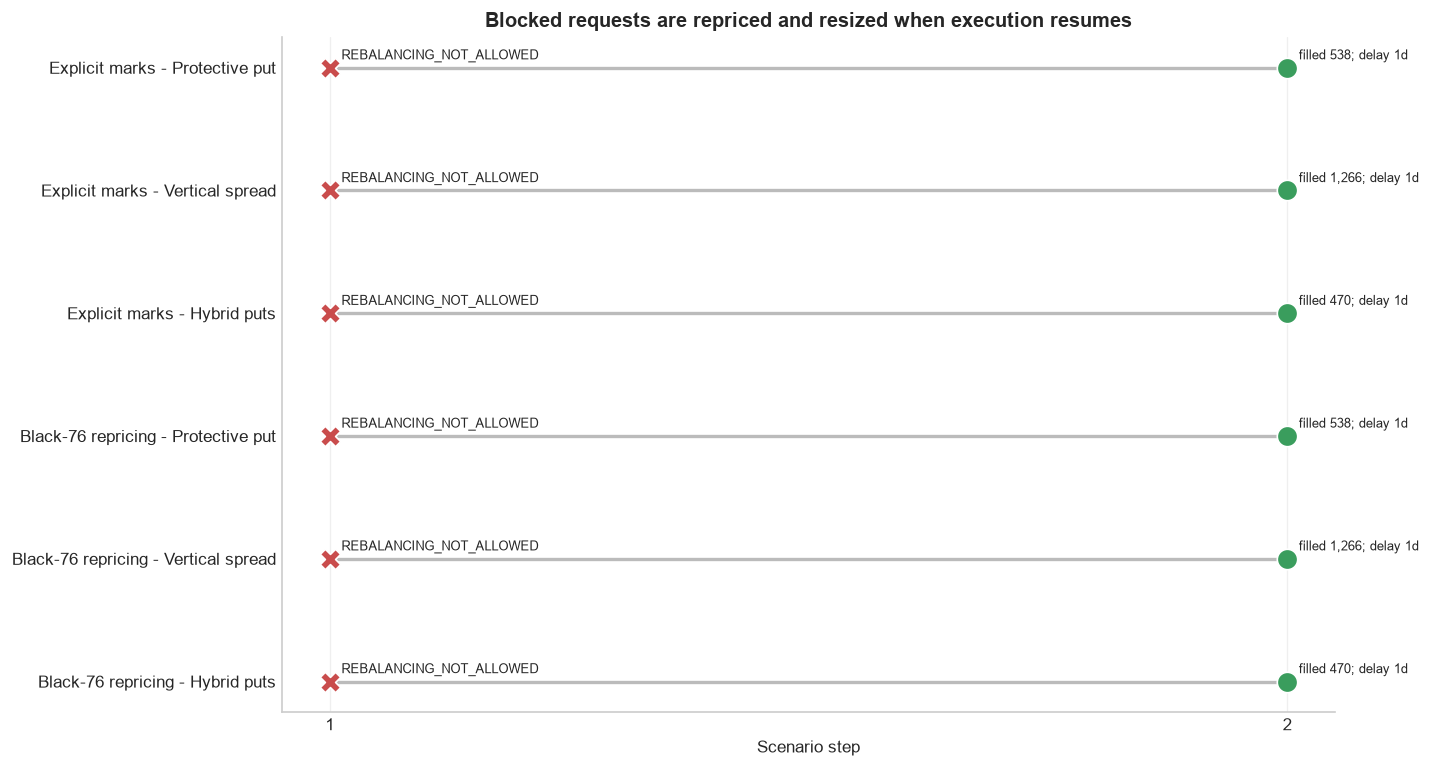

In [5]:
event_rows = []
for mode, batch in batches.items():
    for evaluation in batch.evaluations:
        label = candidate_labels[evaluation.candidate_id]
        for event in evaluation.outcomes[0].rebalance_events:
            event_rows.append({
                'Mode': mode, 'Candidate': label, 'Step': event.step_number,
                'Trigger': event.trigger_type.value,
                'Gross requested contracts': sum(abs(value) for value in event.requested_changes.values()),
                'Gross filled contracts': sum(abs(value) for value in event.filled_changes.values()),
                'Delay': event.delay_trading_days,
                'Turnover / portfolio': float(event.turnover) / portfolio_value,
                'Premium cash flow / portfolio': float(event.premium_cash_flow) / portfolio_value,
                'Execution cost / portfolio': float(event.execution_cost) / portfolio_value,
                'Constraint': event.constraint_result or '-',
                'Failure': event.failure_reason or '-',
            })
events = pd.DataFrame(event_rows).sort_values(['Mode', 'Candidate', 'Step'])
display(events.style.format({
    'Delay': '{:.0f} days', 'Turnover / portfolio': '{:.2%}',
    'Premium cash flow / portfolio': '{:+.3%}', 'Execution cost / portfolio': '{:.3%}',
}).map(lambda value: 'color: #b42318; font-weight: bold' if value != '-' else '', subset=['Failure']))

lanes = [f'{mode} - {candidate}' for mode in modes for candidate in candidates]
fig, ax = plt.subplots(figsize=(12, 6.5))
for lane_index, lane in enumerate(lanes):
    mode, candidate = lane.split(' - ', 1)
    subset = events[(events['Mode'] == mode) & (events['Candidate'] == candidate)]
    ax.plot(subset['Step'], [lane_index] * len(subset), color='#BBBBBB', linewidth=2, zorder=1)
    for _, event in subset.iterrows():
        failed = event['Failure'] != '-'
        ax.scatter(event['Step'], lane_index, s=150, marker='X' if failed else 'o', color='#C94C4C' if failed else '#3A9D5D', edgecolor='white', zorder=3)
        note = event['Failure'] if failed else f"filled {event['Gross filled contracts']:,}"
        if event['Delay']:
            note += f"; delay {event['Delay']}d"
        ax.annotate(note, (event['Step'], lane_index), xytext=(7, 5), textcoords='offset points', fontsize=8)
ax.set_yticks(range(len(lanes)), lanes)
ax.set_xticks(sorted(events['Step'].unique()))
ax.set_xlabel('Scenario step')
ax.set_title('Blocked requests are repriced and resized when execution resumes')
ax.grid(axis='x', alpha=0.3)
ax.grid(axis='y', visible=False)
plt.tight_layout()
plt.show()

## 5. Turnover and incremental execution cost

Lower-left is operationally preferable. Bubble size represents the absolute premium cash flow accumulated across inception and resizing; it is a scale cue, not another pass/fail test.

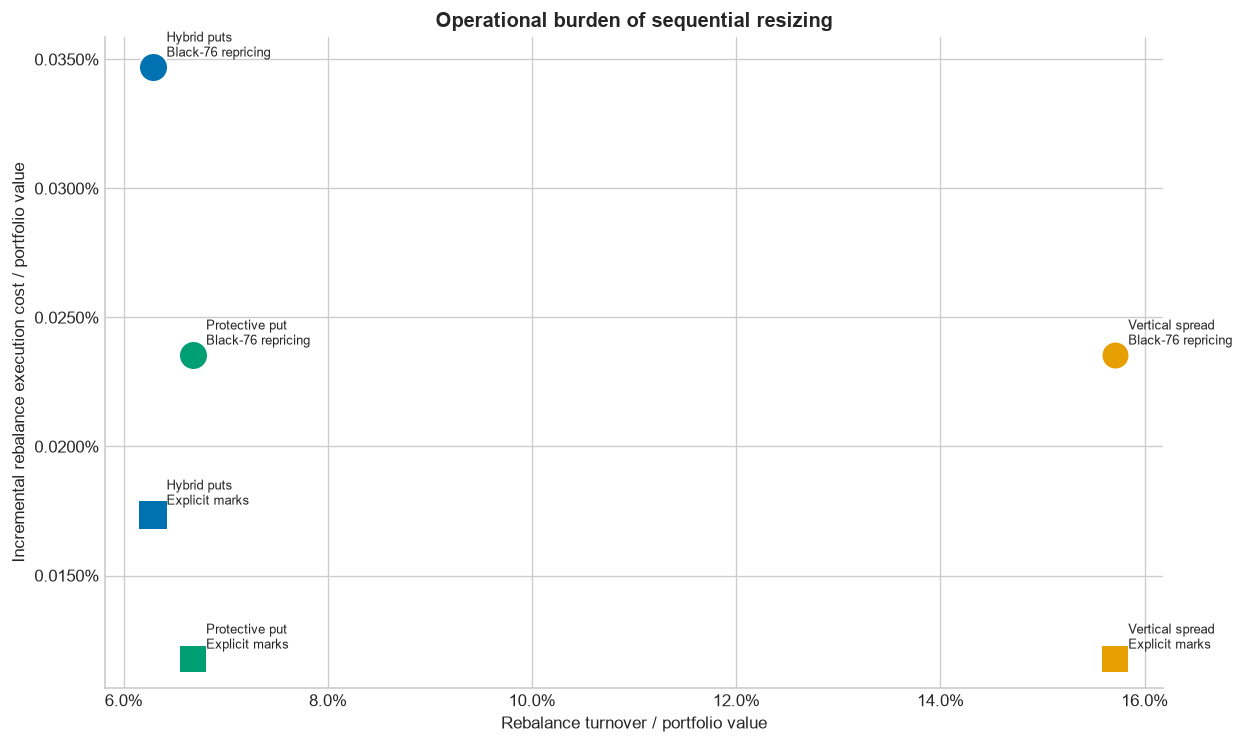

In [6]:
fig, ax = plt.subplots(figsize=(10.5, 6.3))
markers = {'Black-76 repricing': 'o', 'Explicit marks': 's'}
for (mode, candidate), row in summary.iterrows():
    bubble = 250 + 2500 * abs(row['Premium cash flow / portfolio'])
    ax.scatter(
        row['Turnover / portfolio'], row['Rebalance cost / portfolio'], s=bubble,
        color=COLORS[candidate], marker=markers[mode], edgecolor='white', linewidth=1.2, zorder=3,
    )
    ax.annotate(f'{candidate}\n{mode}', (row['Turnover / portfolio'], row['Rebalance cost / portfolio']), xytext=(8, 6), textcoords='offset points', fontsize=8)
ax.set_xlabel('Rebalance turnover / portfolio value')
ax.set_ylabel('Incremental rebalance execution cost / portfolio value')
ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_title('Operational burden of sequential resizing')
plt.tight_layout()
plt.show()

## 6. Decision readout

In [7]:
best_return_key = summary['Rebalanced return'].idxmax()
lowest_turnover_key = summary['Turnover / portfolio'].idxmin()
lowest_cost_key = summary['Rebalance cost / portfolio'].idxmin()
rebalancing_passes = int((summary['Rebalancing gate'] == 'PASS').sum())
overall_passes = int((summary['Overall release gate'] == 'PASS').sum())
display(Markdown(
    f"- **Rebalanced result:** {best_return_key[1]} under {best_return_key[0]} has the least-negative terminal result at {summary.loc[best_return_key, 'Rebalanced return']:.2%}.\n"
    f"- **Turnover:** {lowest_turnover_key[1]} under {lowest_turnover_key[0]} is lowest at {summary.loc[lowest_turnover_key, 'Turnover / portfolio']:.2%} of portfolio value.\n"
    f"- **Incremental execution cost:** {lowest_cost_key[1]} under {lowest_cost_key[0]} is lowest at {summary.loc[lowest_cost_key, 'Rebalance cost / portfolio']:.3%}.\n"
    f"- **Rebalancing gate:** {rebalancing_passes}/{len(summary)} candidate-mode runs pass; delayed execution remains a structured failure even when the later fill completes.\n"
    f"- **Overall release gate:** {overall_passes}/{len(summary)} runs pass every static and sequential check. Red cells must be resolved before recommendation or quoting."
))

- **Rebalanced result:** Vertical spread under Explicit marks has the least-negative terminal result at -15.05%.
- **Turnover:** Hybrid puts under Black-76 repricing is lowest at 6.29% of portfolio value.
- **Incremental execution cost:** Protective put under Explicit marks is lowest at 0.012%.
- **Rebalancing gate:** 0/6 candidate-mode runs pass; delayed execution remains a structured failure even when the later fill completes.
- **Overall release gate:** 0/6 runs pass every static and sequential check. Red cells must be resolved before recommendation or quoting.

---
**Interpretation limits.** These are deterministic, configured stress paths rather than forecasts. Black-76 results depend on configured base volatilities, forwards, and rates; explicit-mark results depend on supplied synthetic marks. Rebalancing targets are recalculated only at scenario steps, fills are limited by configured liquidity and mandate constraints, and a later successful fill does not erase an earlier delay. Index hedges retain basis, gap, model, liquidity, and changing-beta risk. Do not describe any terminal result as a guaranteed portfolio floor.